# Credit Card Fraud Detection
## XGBoost Model Only

**Dataset:** https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

## Step 1: Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

print('All libraries imported successfully!')

All libraries imported successfully!


## Step 2: Load Dataset

In [2]:
df = pd.read_csv('creditcard.csv')

print('Dataset Shape:', df.shape)
print('\nClass Distribution:')
print(df['Class'].value_counts())
print(f'\nFraud Percentage: {df["Class"].mean()*100:.2f}%')
df.head()

Dataset Shape: (284807, 31)

Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud Percentage: 0.17%


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Step 3: Exploratory Data Analysis

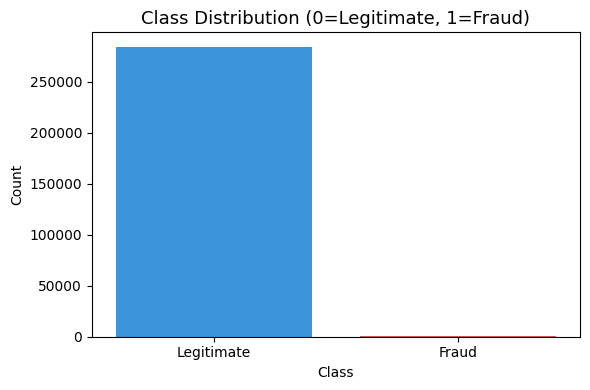

In [3]:
# Class distribution plot
plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=df, palette=['#2196F3', '#F44336'])
plt.title('Class Distribution (0=Legitimate, 1=Fraud)', fontsize=13)
plt.xticks([0, 1], ['Legitimate', 'Fraud'])
plt.ylabel('Count')
plt.tight_layout()
plt.show()

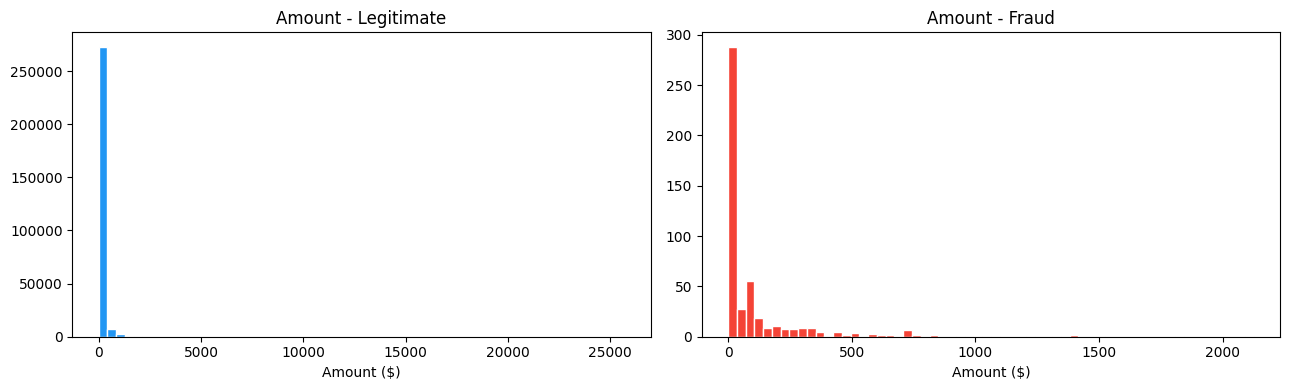

Avg Legitimate Amount : $88.29
Avg Fraud Amount      : $122.21


In [4]:
# Transaction amount by class
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df[df['Class']==0]['Amount'], bins=60, color='#2196F3', edgecolor='white')
axes[0].set_title('Amount - Legitimate')
axes[0].set_xlabel('Amount ($)')

axes[1].hist(df[df['Class']==1]['Amount'], bins=60, color='#F44336', edgecolor='white')
axes[1].set_title('Amount - Fraud')
axes[1].set_xlabel('Amount ($)')

plt.tight_layout()
plt.show()

print(f'Avg Legitimate Amount : ${df[df["Class"]==0]["Amount"].mean():.2f}')
print(f'Avg Fraud Amount      : ${df[df["Class"]==1]["Amount"].mean():.2f}')

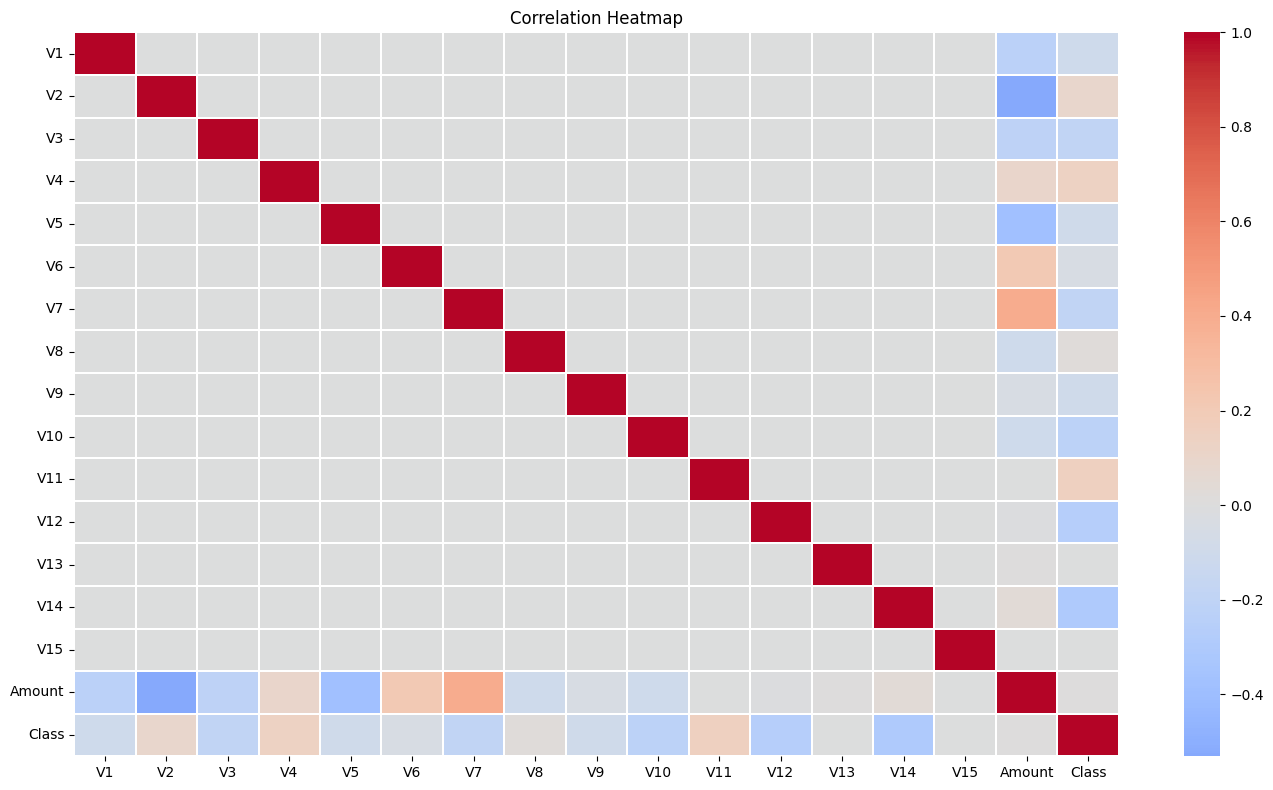

In [5]:
# Correlation heatmap
plt.figure(figsize=(14, 8))
cols = ['V1','V2','V3','V4','V5','V6','V7','V8','V9','V10',
        'V11','V12','V13','V14','V15','Amount','Class']
sns.heatmap(df[cols].corr(), cmap='coolwarm', center=0,
            annot=False, linewidths=0.3)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

## Step 4: Preprocessing

In [6]:
# Scale Amount and Time
data = df.copy()
scaler = StandardScaler()
data['scaled_Amount'] = scaler.fit_transform(data['Amount'].values.reshape(-1,1))
data['scaled_Time']   = scaler.fit_transform(data['Time'].values.reshape(-1,1))
data.drop(['Amount','Time'], axis=1, inplace=True)

print('Scaling done. Shape:', data.shape)

Scaling done. Shape: (284807, 31)


In [7]:
# Split features and target
X = data.drop('Class', axis=1)
y = data['Class']

# Train-test split (80/20 stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train shape:', X_train.shape)
print('Test shape :', X_test.shape)

Train shape: (227845, 30)
Test shape : (56962, 30)


After SMOTE training shape: (454902, 30)
Class distribution: {0: 227451, 1: 227451}


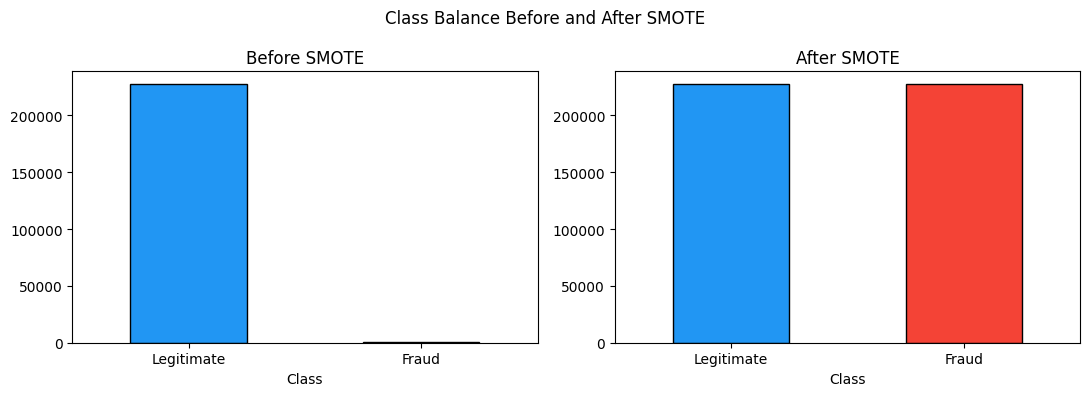

In [8]:
# Apply SMOTE to balance training data
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print('After SMOTE training shape:', X_train_sm.shape)
print('Class distribution:', pd.Series(y_train_sm).value_counts().to_dict())

# Plot before/after SMOTE
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
pd.Series(y_train).value_counts().plot(kind='bar', ax=axes[0],
    color=['#2196F3','#F44336'], edgecolor='black')
axes[0].set_title('Before SMOTE')
axes[0].set_xticklabels(['Legitimate','Fraud'], rotation=0)

pd.Series(y_train_sm).value_counts().plot(kind='bar', ax=axes[1],
    color=['#2196F3','#F44336'], edgecolor='black')
axes[1].set_title('After SMOTE')
axes[1].set_xticklabels(['Legitimate','Fraud'], rotation=0)

plt.suptitle('Class Balance Before and After SMOTE')
plt.tight_layout()
plt.show()

## Step 5: Train XGBoost Model

In [9]:
print('Training XGBoost model...')

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=1,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

xgb_model.fit(X_train_sm, y_train_sm)

print('Training complete!')

Training XGBoost model...
Training complete!


## Step 6: Evaluate Model

In [10]:
# Predictions
y_pred  = xgb_model.predict(X_test)
y_proba = xgb_model.predict_proba(X_test)[:, 1]

# Metrics
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
auc  = roc_auc_score(y_test, y_proba)

print('=' * 50)
print('  XGBoost Model Results')
print('=' * 50)
print(f'  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)')
print(f'  Precision : {prec:.4f}')
print(f'  Recall    : {rec:.4f}')
print(f'  F1 Score  : {f1:.4f}')
print(f'  ROC-AUC   : {auc:.4f}')
print('=' * 50)
print('\nClassification Report:')
print(classification_report(y_test, y_pred,
      target_names=['Legitimate (0)', 'Fraud (1)']))

  XGBoost Model Results
  Accuracy  : 0.9974  (99.74%)
  Precision : 0.3857
  Recall    : 0.8776
  F1 Score  : 0.5358
  ROC-AUC   : 0.9760

Classification Report:
                precision    recall  f1-score   support

Legitimate (0)       1.00      1.00      1.00     56864
     Fraud (1)       0.39      0.88      0.54        98

      accuracy                           1.00     56962
     macro avg       0.69      0.94      0.77     56962
  weighted avg       1.00      1.00      1.00     56962



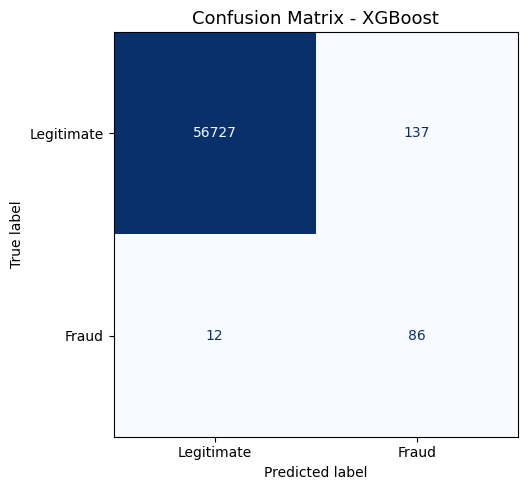

True Negatives  (Correct Legitimate) : 56727
False Positives (Legitimate as Fraud): 137
False Negatives (Fraud missed)       : 12
True Positives  (Fraud caught)       : 86


In [11]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Legitimate', 'Fraud'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix - XGBoost', fontsize=13)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Negatives  (Correct Legitimate) : {tn}')
print(f'False Positives (Legitimate as Fraud): {fp}')
print(f'False Negatives (Fraud missed)       : {fn}')
print(f'True Positives  (Fraud caught)       : {tp}')

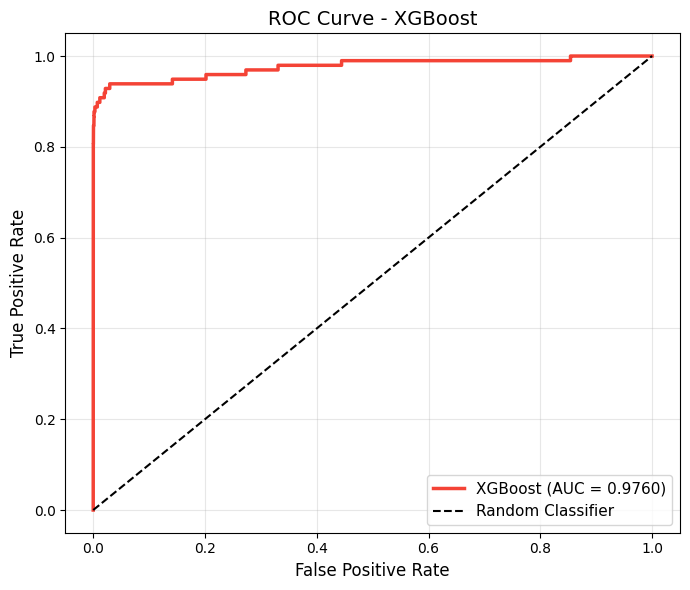

In [12]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='#F44336', lw=2.5,
         label=f'XGBoost (AUC = {auc:.4f})')
plt.plot([0,1],[0,1],'k--', lw=1.5, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - XGBoost', fontsize=14)
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Step 7: Feature Importance

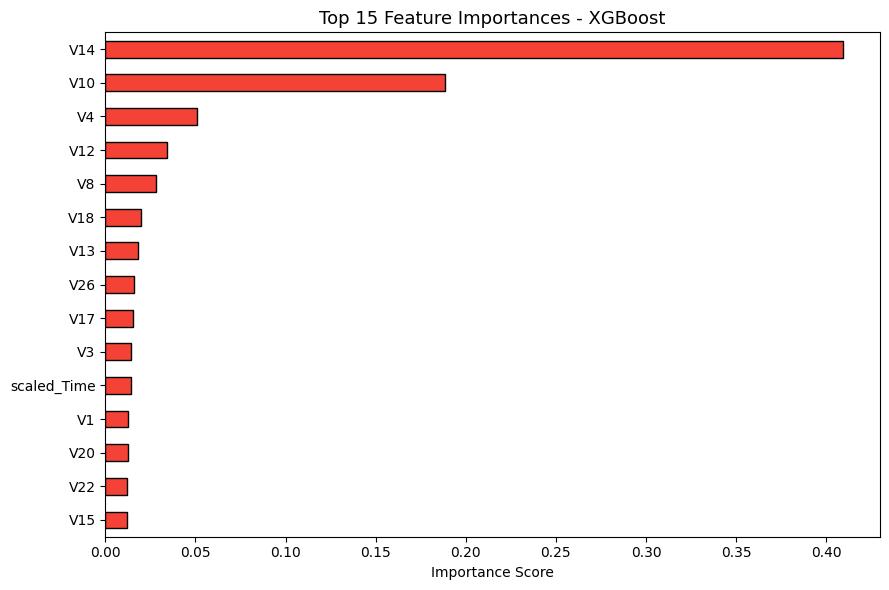

Top 5 Most Important Features:
V14    0.409384
V10    0.188464
V4     0.050835
V12    0.034432
V8     0.027979


In [13]:
# Top 15 important features
feat_imp = pd.Series(xgb_model.feature_importances_, index=X.columns)
top15 = feat_imp.nlargest(15)

plt.figure(figsize=(9, 6))
top15.sort_values().plot(kind='barh', color='#F44336', edgecolor='black')
plt.title('Top 15 Feature Importances - XGBoost', fontsize=13)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('Top 5 Most Important Features:')
print(feat_imp.nlargest(5).to_string())

## Step 8: Cross Validation

In [14]:
print('Running 5-Fold Cross Validation...')

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_cv = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

f1_scores  = cross_val_score(xgb_cv, X, y, cv=cv, scoring='f1')
auc_scores = cross_val_score(xgb_cv, X, y, cv=cv, scoring='roc_auc')

print('=' * 45)
print('  XGBoost 5-Fold Cross Validation Results')
print('=' * 45)
print(f'  F1 Scores  : {f1_scores}')
print(f'  Mean F1    : {f1_scores.mean():.4f}')
print(f'  Std Dev    : {f1_scores.std():.4f}')
print(f'  Mean AUC   : {auc_scores.mean():.4f}')
print('=' * 45)

Running 5-Fold Cross Validation...
  XGBoost 5-Fold Cross Validation Results
  F1 Scores  : [0.84090909 0.90217391 0.87777778 0.84916201 0.86486486]
  Mean F1    : 0.8670
  Std Dev    : 0.0217
  Mean AUC   : 0.9806


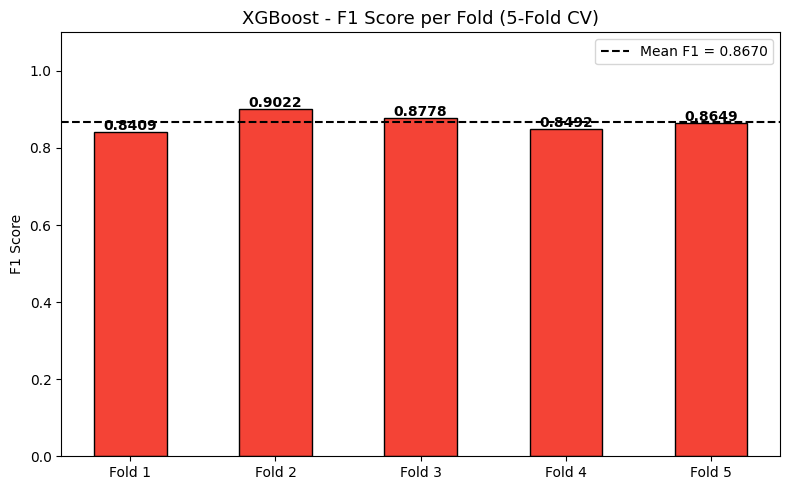

In [15]:
# Plot CV scores per fold
plt.figure(figsize=(8, 5))
folds = [f'Fold {i+1}' for i in range(5)]
plt.bar(folds, f1_scores, color='#F44336', edgecolor='black', width=0.5)
plt.axhline(y=f1_scores.mean(), color='black', linestyle='--',
            linewidth=1.5, label=f'Mean F1 = {f1_scores.mean():.4f}')
for i, v in enumerate(f1_scores):
    plt.text(i, v + 0.005, f'{v:.4f}', ha='center', fontsize=10, fontweight='bold')
plt.title('XGBoost - F1 Score per Fold (5-Fold CV)', fontsize=13)
plt.ylabel('F1 Score')
plt.ylim(0, 1.1)
plt.legend()
plt.tight_layout()
plt.show()

## Step 9: Summary

In [16]:
print('=' * 50)
print('  XGBOOST MODEL - FINAL SUMMARY')
print('=' * 50)
print(f'  Accuracy       : {acc:.4f}  ({acc*100:.2f}%)')
print(f'  Precision      : {prec:.4f}')
print(f'  Recall         : {rec:.4f}')
print(f'  F1 Score       : {f1:.4f}')
print(f'  ROC-AUC Score  : {auc:.4f}')
print(f'  CV Mean F1     : {f1_scores.mean():.4f}')
print(f'  CV Mean AUC    : {auc_scores.mean():.4f}')
print('=' * 50)
print()
print('Key Findings:')
print('  - XGBoost effectively detects credit card fraud')
print('  - SMOTE improved recall for minority fraud class')
print('  - V14, V17, V12 are the top fraud indicators')
print('=' * 50)

  XGBOOST MODEL - FINAL SUMMARY
  Accuracy       : 0.9974  (99.74%)
  Precision      : 0.3857
  Recall         : 0.8776
  F1 Score       : 0.5358
  ROC-AUC Score  : 0.9760
  CV Mean F1     : 0.8670
  CV Mean AUC    : 0.9806

Key Findings:
  - XGBoost effectively detects credit card fraud
  - SMOTE improved recall for minority fraud class
  - V14, V17, V12 are the top fraud indicators
